# Evaluating the prediction performance in space

Looking at two error metrics:

- The differenc in the slope of a linear regression in time at every grid point (as an indicator of the ability to reproduce long term trends, one of the main goals of our project)
- The RMSE over the entire rollout. This is more similar to the training, but at no point in the training are we looking at such long rollouts.


>[!WARNING]
>Make sure to install the ocean_emulator package, or these imports below will fail

In [1]:
!pip install -e ../

Obtaining file:///home/jovyan/PROJECTS/ocean_emulators
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Using cached xarray_schema-0.0.3-py3-none-any.whl.metadata (4.3 kB)
  Using cached xgcm-0.6.1-py3-none-any.whl.metadata (6.0 kB)
Using cached xarray_schema-0.0.3-py3-none-any.whl (10 kB)
Using cached xgcm-0.6.1-py3-none-any.whl (60 kB)
  Building editable for ocean_emulators (pyproject.toml) ... done
  Created wheel for ocean_emulators: filename=ocean_emulators-0.1.dev138+g6d5c763.d20240822-0.editable-py3-none-any.whl size=9927 sha256=1f7b2592e33b7631fa36038d925178311ae00055e048219719efc97aa6033543
  Stored in directory: /tmp/pip-ephem-wheel-cache-qxb9ftsn/wheels/2f/06/70/2410470da35c3e11f97c0783419e431821927d9cfb53cda80d
Successfully built ocean_emulators
  Attempting uninstall: xgcm
    Found existing installation: xgcm 0.8

In [1]:
import xarray as xr
from ocean_emulators.postprocessing import post_processor
from dask.diagnostics import ProgressBar
from xarrayutils.plotting import linear_piecewise_scale
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
with ProgressBar():
    url_input = "gs://leap-persistent/jbusecke/ocean-emulators/OM4_5daily_v0.2.1.zarr"
    ds = xr.open_dataset(url_input, engine='zarr', chunks={})
    ds_truth = ds.isel(time=slice(4143, 4743)).astype('float32').chunk({'time':10, 'x':-1, 'y':-1, 'lev':-1})
    
    url_prediction = "gs://leap-persistent/sd5313/convnext_epoch-70_train-OM4v0.2.1_eval-OM4v0.2.1"
    ds_pred_raw = xr.open_dataset(url_prediction, engine='zarr')
    ds_pred = post_processor(ds_pred_raw, ds_truth).astype('float32').chunk({'time':10, 'x':-1, 'y':-1, 'lev':-1})

/home/jovyan/PROJECTS/ocean_emulators/ocean_emulators/postprocessing.py:20: UserWarning: Swapped x and y dimensions detected. Fixing this now, but should be corrected upstream
  warnings.warn(


>[!NOTE]
>For Surya: Lets figure out the chunking issue so you can upload the fully postprocessed data to the cloud

In [5]:
# combine truth and prediction into a single dataset for convenience. 

ds_combined = xr.concat([ds_truth[[*list(ds_pred.data_vars)]].assign_coords(model='truth'), ds_pred.assign_coords(model='prediction')], dim='model')
ds_combined

<xarray.Dataset> Size: 24GB
Dimensions:         (model: 2, time: 600, lev: 19, y: 180, x: 360, y_b: 181,
                     x_b: 361)
Coordinates: (12/13)
    areacello       (y, x) float64 518kB dask.array<chunksize=(180, 360), meta=np.ndarray>
    dz              (lev) int64 152B dask.array<chunksize=(19,), meta=np.ndarray>
    lat             (y, x) float64 518kB dask.array<chunksize=(180, 360), meta=np.ndarray>
  * lev             (lev) float64 152B 2.5 10.0 22.5 40.0 ... 4e+03 5e+03 6e+03
    lon             (y, x) float64 518kB dask.array<chunksize=(180, 360), meta=np.ndarray>
    ocean_fraction  (lev, y, x) float64 10MB dask.array<chunksize=(19, 180, 360), meta=np.ndarray>
    ...              ...
    wetmask         (lev, y, x) bool 1MB dask.array<chunksize=(19, 180, 360), meta=np.ndarray>
  * x               (x) float64 3kB 0.5 1.5 2.5 3.5 ... 356.5 357.5 358.5 359.5
  * y               (y) float64 1kB -89.24 -88.25 -87.25 ... 87.25 88.25 89.24
  * model           (model) <U10 80B 'truth' 'prediction'
    lat_b           (y_b, x_b) float64 523kB dask.array<chunksize=(91, 361), meta=np.ndarray>
    lon_b           (y_b, x_b) float64 523kB dask.array<chunksize=(91, 361), meta=np.ndarray>
Dimensions without coordinates: y_b, x_b
Data variables:
    uo              (model, time, lev, y, x) float32 6GB dask.array<chunksize=(1, 10, 19, 180, 360), meta=np.ndarray>
    vo              (model, time, lev, y, x) float32 6GB dask.array<chunksize=(1, 10, 19, 180, 360), meta=np.ndarray>
    thetao          (model, time, lev, y, x) float32 6GB dask.array<chunksize=(1, 10, 19, 180, 360), meta=np.ndarray>
    so              (model, time, lev, y, x) float32 6GB dask.array<chunksize=(1, 10, 19, 180, 360), meta=np.ndarray>
    zos             (model, time, y, x) float32 311MB dask.array<chunksize=(1, 10, 180, 360), meta=np.ndarray>
Attributes:
    m2lines/ocean-emulators_git_hash:  https://github.com/m2lines/ocean_emula...
    regrid_method:                     conservative

In [6]:
# Getting the trend by fitting a 2nd deg poly, and only retaining the second coefficient (the first is the mean).
trend = ds_combined.polyfit('time', deg=1).isel(degree=1)
with ProgressBar():
    trend = trend.load()
trend_diff = trend.diff('model')
trend_diff

[########################################] | 100% Completed | 17m 55s


<xarray.Dataset> Size: 40MB
Dimensions:                      (model: 1, lev: 19, y: 180, x: 360)
Coordinates:
  * model                        (model) object 8B 'prediction'
  * lev                          (lev) float64 152B 2.5 10.0 ... 5e+03 6e+03
  * y                            (y) float64 1kB -89.24 -88.25 ... 88.25 89.24
  * x                            (x) float64 3kB 0.5 1.5 2.5 ... 358.5 359.5
    degree                       int64 8B 0
Data variables:
    uo_polyfit_coefficients      (model, lev, y, x) float64 10MB nan nan ... nan
    vo_polyfit_coefficients      (model, lev, y, x) float64 10MB nan nan ... nan
    thetao_polyfit_coefficients  (model, lev, y, x) float64 10MB nan nan ... nan
    so_polyfit_coefficients      (model, lev, y, x) float64 10MB nan nan ... nan
    zos_polyfit_coefficients     (model, y, x) float64 518kB nan nan ... 0.2155
Attributes:
    m2lines/ocean-emulators_git_hash:  https://github.com/m2lines/ocean_emula...
    regrid_method:                     conservative

In [7]:
# Compute the RMSE
rmse = (ds_combined.diff('model')**2).mean('time')
with ProgressBar():
    rmse = rmse.load()
rmse

[########################################] | 100% Completed | 23.06 s


<xarray.Dataset> Size: 34MB
Dimensions:         (y: 180, x: 360, lev: 19, model: 1, y_b: 181, x_b: 361)
Coordinates:
    areacello       (y, x) float64 518kB 1.699e+08 1.699e+08 ... 1.699e+08
    dz              (lev) int64 152B 5 10 15 20 30 50 ... 600 800 1000 1000 1000
    lat             (y, x) float64 518kB -89.24 -89.24 -89.24 ... 89.24 89.24
  * lev             (lev) float64 152B 2.5 10.0 22.5 40.0 ... 4e+03 5e+03 6e+03
    lon             (y, x) float64 518kB 0.5 1.5 2.5 3.5 ... 357.5 358.5 359.5
    ocean_fraction  (lev, y, x) float64 10MB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    wetmask         (lev, y, x) bool 1MB False False False ... False False False
  * x               (x) float64 3kB 0.5 1.5 2.5 3.5 ... 356.5 357.5 358.5 359.5
  * y               (y) float64 1kB -89.24 -88.25 -87.25 ... 87.25 88.25 89.24
  * model           (model) <U10 40B 'prediction'
    lat_b           (y_b, x_b) float64 523kB -90.0 -90.0 -90.0 ... 90.0 90.0
    lon_b           (y_b, x_b) float64 523kB 0.0 1.0 2.0 ... 358.0 359.0 360.0
Dimensions without coordinates: y_b, x_b
Data variables:
    uo              (model, lev, y, x) float32 5MB nan nan nan ... nan nan nan
    vo              (model, lev, y, x) float32 5MB nan nan nan ... nan nan nan
    thetao          (model, lev, y, x) float32 5MB nan nan nan ... nan nan nan
    so              (model, lev, y, x) float32 5MB nan nan nan ... nan nan nan
    zos             (model, y, x) float32 259kB nan nan ... 0.005333 0.005108

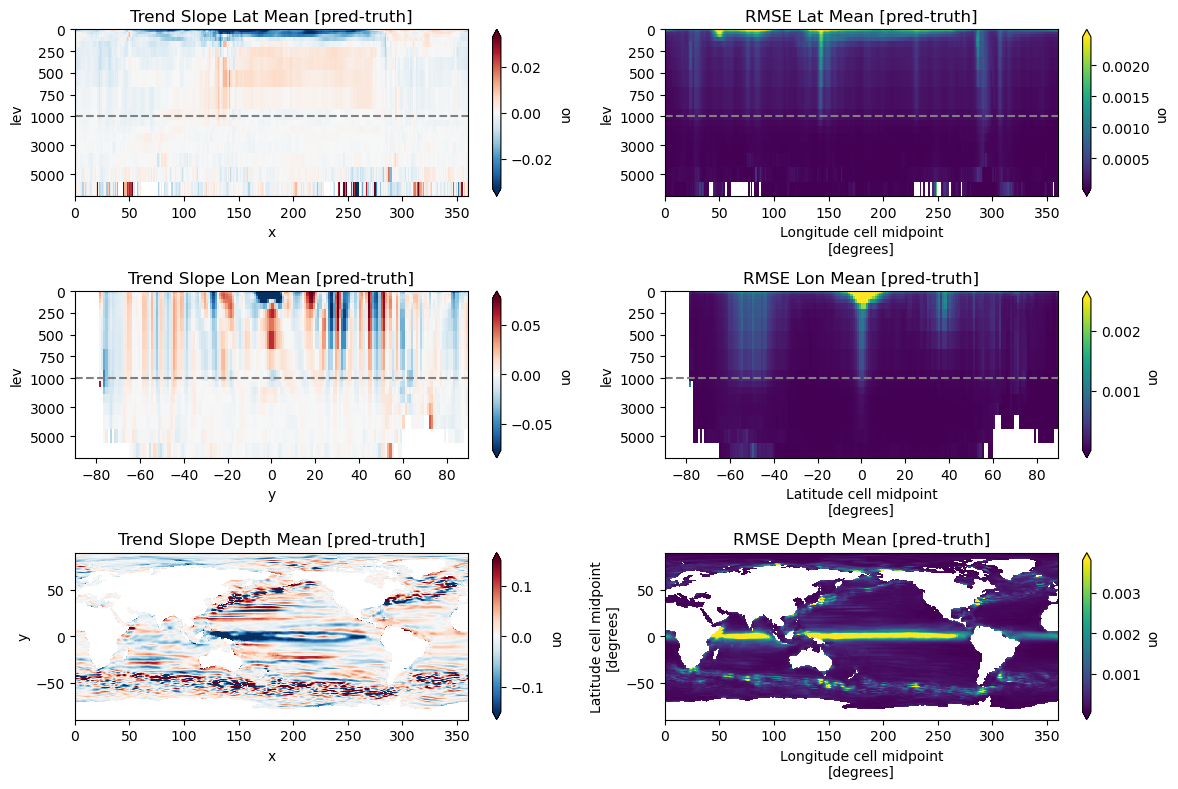

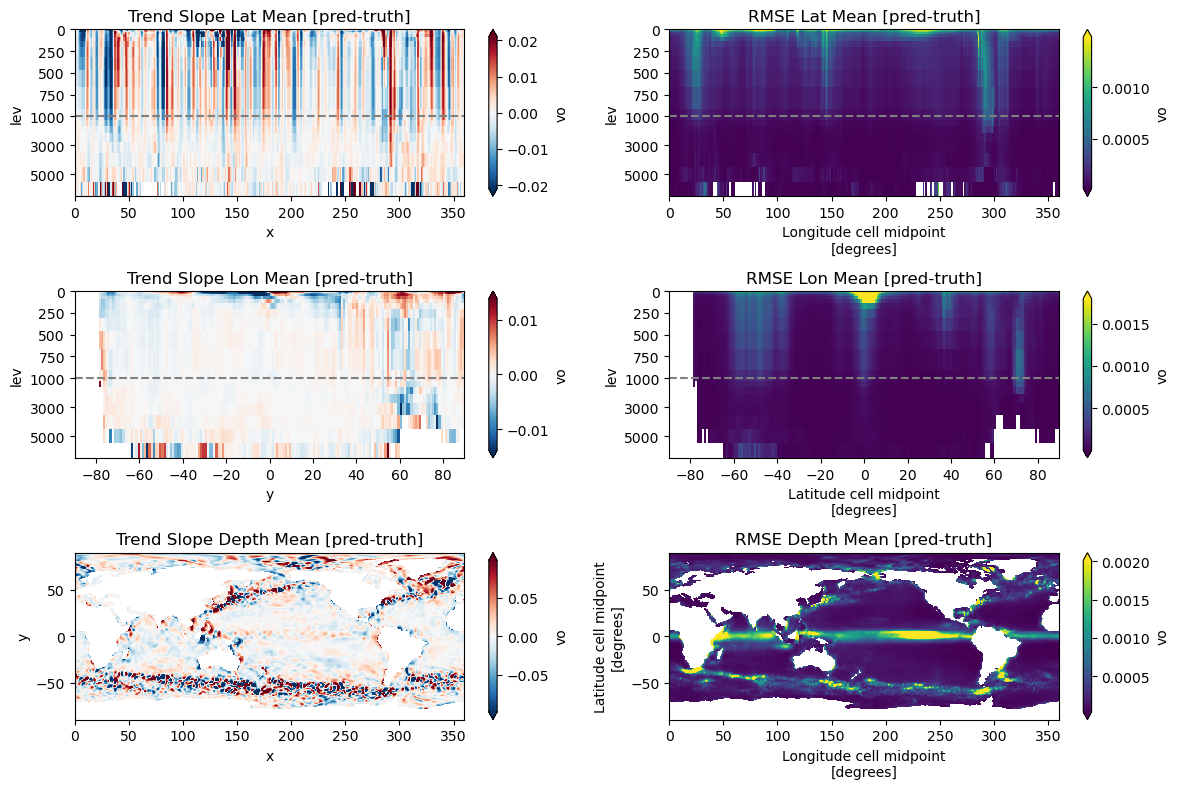

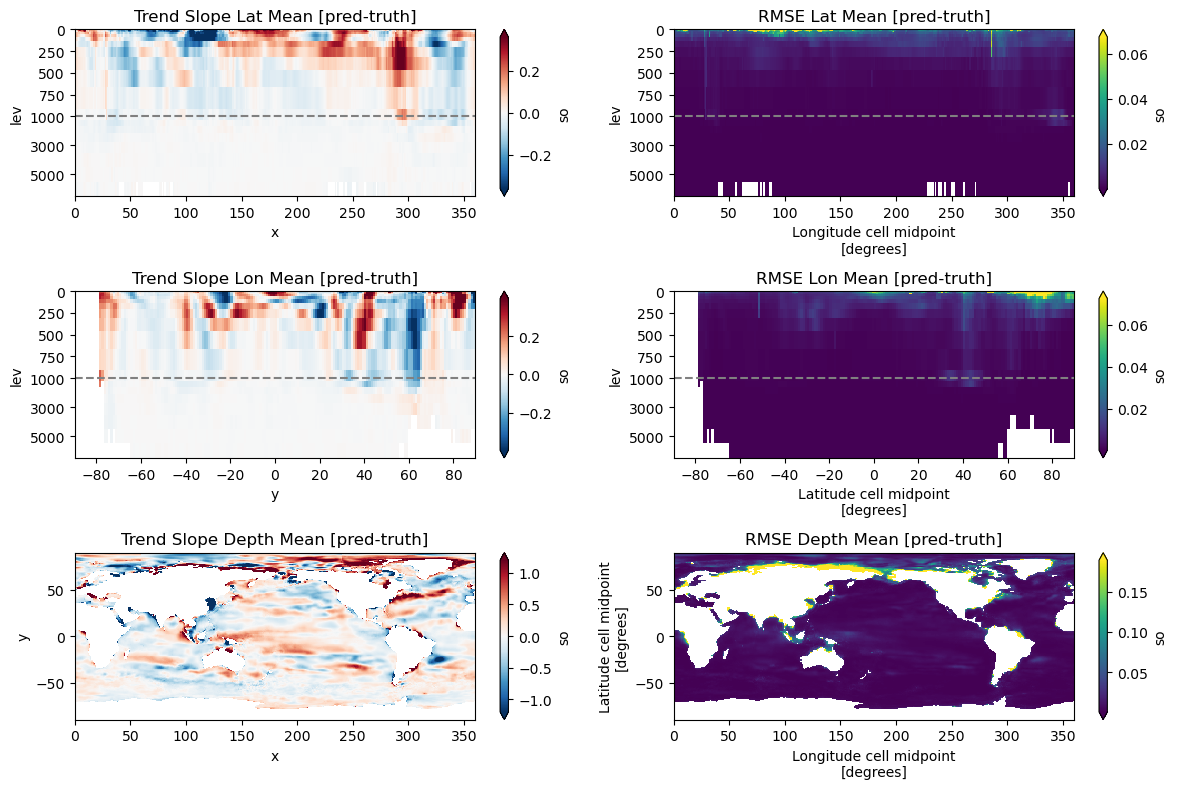

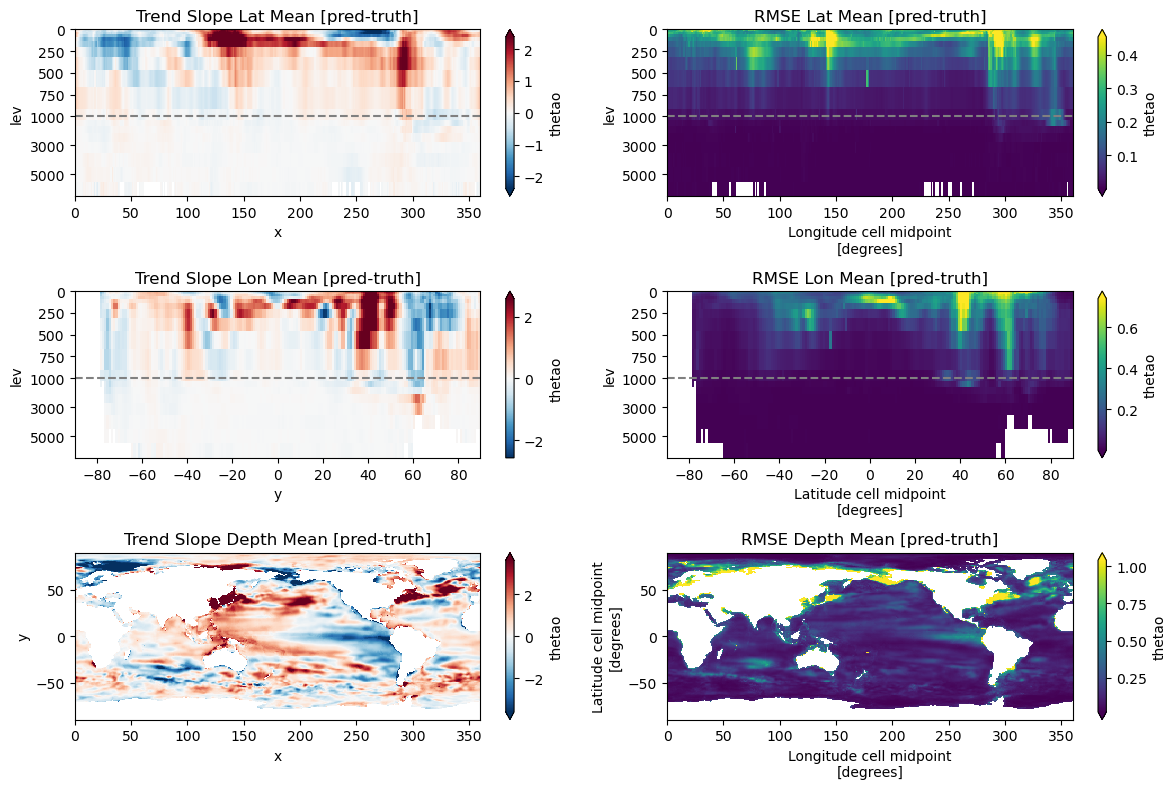

In [8]:
# Prototype plots
kwargs = {'robust':True}

for var in ['uo', 'vo', 'so', 'thetao']:


    da = trend_diff[f"{var}_polyfit_coefficients"].squeeze().reset_coords(drop=True)
    da.name = var

    plt.figure(figsize=[12,8])
    plt.subplot(3,2,1)
    da.mean('y').plot(yincrease=False, **kwargs)
    ax = plt.gca()
    linear_piecewise_scale(1000, 5)
    #indicate the point between the different scalings
    ax.axhline(1000, color='0.5', ls='--')
    # Rearange the yticks
    ax.set_yticks([0, 250, 500, 750, 1000, 3000, 5000])
    ax.set_title('Trend Slope Lat Mean [pred-truth]')
    
    plt.subplot(3,2,3)
    da.mean('x').plot(yincrease=False, **kwargs)
    ax = plt.gca()
    linear_piecewise_scale(1000, 5)
    #indicate the point between the different scalings
    ax.axhline(1000, color='0.5', ls='--')
    # Rearange the yticks
    ax.set_yticks([0, 250, 500, 750, 1000, 3000, 5000]);
    ax.set_title('Trend Slope Lon Mean [pred-truth]')
    
    plt.subplot(3,2,5)
    ax = plt.gca()
    da.mean('lev').plot(**kwargs)
    ax.set_title('Trend Slope Depth Mean [pred-truth]')

    da = rmse[var].squeeze().reset_coords(drop=True)

    plt.subplot(3,2,2)
    da.mean('y').plot(yincrease=False, **kwargs)
    ax = plt.gca()
    linear_piecewise_scale(1000, 5)
    #indicate the point between the different scalings
    ax.axhline(1000, color='0.5', ls='--')
    # Rearange the yticks
    ax.set_yticks([0, 250, 500, 750, 1000, 3000, 5000]);
    ax.set_title('RMSE Lat Mean [pred-truth]')
    
    plt.subplot(3,2,4)
    da.mean('x').plot(yincrease=False, **kwargs)
    ax = plt.gca()
    linear_piecewise_scale(1000, 5)
    #indicate the point between the different scalings
    ax.axhline(1000, color='0.5', ls='--')
    # Rearange the yticks
    ax.set_yticks([0, 250, 500, 750, 1000, 3000, 5000]);
    ax.set_title('RMSE Lon Mean [pred-truth]')
    
    plt.subplot(3,2,6)
    ax = plt.gca()
    da.mean('lev').plot(**kwargs)
    ax.set_title('RMSE Depth Mean [pred-truth]')
    plt.tight_layout()